# Lab4: Exact Inference on Factor Graphs playing Scotland Yard

## Motivation

Scotland Yard is a board game where **Mr. X** moves secretly through a city while $n$ **detective agents** try to catch him. At each turn, Mr. X reveals *which transport* he used (taxi, bus, metro) but not his destination. The agents know their own positions and must reason about where Mr. X is hiding.

This is a canonical problem of **inference in a partially observed dynamical system**, and it maps beautifully onto exact Bayesian inference via the **Sum-Product Algorithm** on a **factor graph**.

## 1 — Why a Factor Graph?

### 1.1 The joint distribution of the system

Let $T$ be the number of turns and $n$ the number of agents. Define:

| Symbol | Meaning | Observed? |
|--------|---------|----------|
| $x_t \in V$ | position of Mr. X at turn $t$ | **No** (latent) |
| $m_t \in \{\text{taxi, bus, metro}\}$ | transport used by Mr. X at turn $t$ | **Yes** (revealed) |
| $a^i_t \in V$ | position of agent $i$ at turn $t$ | **Yes** (known) |

The joint distribution over all positions factorises as:

$$p(x_{0:T},\, a^{1:n}_{0:T}) = p(x_0) \prod_{t=1}^{T} f_{\text{move}}(x_t, x_{t-1}, m_t) \cdot \prod_{t=0}^{T} f_{\text{obs}}(x_t, a^{1:n}_t)$$

where:

- $f_{\text{move}}(x_t, x_{t-1}, m_t)$ is the probability of Mr. X to choose position $x_t$ starting from position $x_{t-1}$ and using transport $m_t$:
$$f_{\text{move}}(x_t, x_{t-1}, m_t) = \frac{\mathbb{1}\bigl[(x_{t-1}, x_t) \in E_{m_t}\bigr]}{|\mathcal{N}_{m_t}(x_{t-1})|}$$
i.e. uniform over neighbours reachable by transport $m_t$, zero elsewhere.

- Mr. X cannot stand on a node already occupied by an agent:
$$f_{\text{obs}}(x_t, a^{1:n}_t) = \prod_{i=1}^{n} \mathbb{1}\bigl[x_t \neq a^i_t\bigr]$$
this probability is zero if agent $i$ is in $x_t$ (position of Mr. X) at time $t$

### 1.2 This is a Factor Graph

A **factor graph** $\mathcal{F} = (\mathcal{V}, \mathcal{F}, \mathcal{E})$ is a bipartite graph with:
- **Variable nodes** $\mathcal{V}$: one per random variable
- **Factor nodes** $\mathcal{F}$: one per factor $f_k$
- **Edges**: variable $x$ is connected to factor $f_k$ iff $x$ appears in the argument of $f_k$

Our system has the following factor graph structure over the latent variable chain:

```
  [x_0] ──── (f_move,1) ──── [x_1] ──── (f_move,2) ──── [x_2] ── ... ── [x_T]
    |                           |                           |
 (f_obs,0)                 (f_obs,1)                  (f_obs,2)
```

This is a **tree** (chain): the Sum-Product Algorithm computes **exact** marginals on trees.

### 1.3 What we want to compute 
The entire purpose of modeling this game is to be able to compute the *exact uncertainty about Mr. X's position at any given time*. In probabilistic terms, this uncertainty is the **marginal distribution** (or *belief*). In our lab, we will compute this marginal for two completely different purposes, which correspond to two different ways of using the Sum-Product Algorithm:

#### Goal 1: Real-time pursuit (called `filtering`)
During the game, the detectives cannot predict the future. They must decide where to move at turn $t$ based **only** on the information collected up to that moment (the transports used and the past positions). 
Therefore, we want to compute the *filtered belief on Mr. X's position*:

$$b_t(x_t) = p(x_t \mid m_{1:t},\, a^{1:n}_{0:t}) \propto \alpha_t(x_t)$$

* mathematically speaking, it is proportional to the **forward message ($\alpha_t$)** of the Sum-Product Algorithm.
* $\alpha_t$ is a real-time "radar": the detectives (agents) will look at this probability vector and move toward the map nodes where $\alpha_t$ has the highest value.

#### Goal 2: Post-game analysis (called full `smoothing`)
Imagine the game is over and Mr. X escaped at turn $T$. The detectives sit at a table and analyze the **entire sequence** of used tickets ($1 \ldots T$). They want to answer the question: *"With hindsight, knowing what he did next, where exactly was Mr. X at turn 2?"*
Therefore, we want to compute the *smoothed belief*:

$$b_t^{\text{smooth}}(x_t) = p(x_t \mid m_{1:T},\, a^{1:n}_{0:T}) \propto \alpha_t(x_t) \cdot \beta_t(x_t)$$

* mathematically speaking, it is proportional to the element-wise product of the forward message ($\alpha_t$) and the **backward message ($\beta_t$)** (this is the true and complete Sum-Product Algorithm described in Chapter 4!).
* to visually demonstrate how information travels "from the future to the past" in the Factor Graph, we will compute $\beta_t$ and discover that the high uncertainty they had at turn 2 drops drastically once the information from turns 3, 4, and 5 is integrated.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import defaultdict
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


---
## 2 — The Map: a Spatial Labelled Multigraph

The game map is a **labelled multigraph** $G = (V, E)$ where:
- **Nodes** $V$: locations (50 nodes — extended map)
- **Edges** $E$: connections labelled by transport type

Not every pair of nodes is connected — and not every node supports all transport types. This **sparse, heterogeneous connectivity** is what makes each transport observation informative: knowing which mode was used rules out large regions of the map.

The **transition factor** for transport $m$ between nodes $u$ and $v$ is:

$$[T_m]_{u,v} = \frac{\mathbb{1}[(u,v) \in E_m]}{\deg_m(u)}, \qquad \deg_m(u) = |\mathcal{N}_m(u)|$$

This gives a **row-stochastic** matrix $T_m \in [0,1]^{|V| \times |V|}$ for each transport mode (rows with no edges are all-zero, meaning that transport is unavailable from that node).

In [2]:
class ScotlandYardMap:
    """
    The game map as a labelled multigraph.
    Each edge carries a 'transport' attribute in {'taxi', 'bus', 'metro'}.

    Design:
      - Taxi  : dense, local connections
      - Bus   : sparser, medium-range
      - Metro : few edges, long-range hubs
    """

    TRANSPORT_COLORS = {'taxi': '#F4D03F', 'bus': '#2ECC71', 'metro': '#3498DB'}

    def __init__(self):
        self.G = nx.MultiGraph()
        self._build()

    def _build(self):
        positions = {
             1:(1.0,8.5),  2:(2.5,9.0),  3:(4.0,9.2),  4:(5.5,9.0),
             5:(7.0,9.0),  6:(2.0,7.5),  7:(3.5,7.8),  8:(5.0,8.0),
             9:(6.5,7.8), 10:(8.0,8.5), 11:(1.5,6.5), 12:(3.0,6.5),
            13:(4.5,6.8), 14:(6.0,6.5), 15:(7.5,6.8), 16:(9.0,7.0),
            17:(2.0,5.5), 18:(3.5,5.5), 19:(5.0,5.8), 20:(6.5,5.5),
            21:(8.0,5.5), 22:(1.5,4.5), 23:(3.0,4.5), 24:(4.5,4.5),
            25:(6.0,4.5), 26:(7.5,4.5), 27:(9.0,5.0), 28:(2.0,3.5),
            29:(3.5,3.5), 30:(5.0,3.5), 31:(6.5,3.5), 32:(8.0,3.5),
            33:(3.0,2.5), 34:(5.0,2.5), 35:(7.0,2.5),
             36:(3.0,1.5), 37:(5.0,1.5), 38:(7.0,1.5),
            39:(2.0,0.8), 40:(4.0,0.8), 41:(6.0,0.8), 42:(8.0,0.8),
            43:(1.0,0.2), 44:(3.5,0.2), 45:(5.5,0.2), 46:(7.5,0.2),
            47:(0.5,4.0), 48:(9.5,4.0), 49:(0.5,2.0), 50:(9.5,2.0),
        }
        for node, pos in positions.items():
            self.G.add_node(node, pos=pos)

        taxi_edges = [
            (1,2),(2,3),(3,4),(4,5),(1,6),(2,6),(2,7),(3,7),(3,8),
            (4,8),(4,9),(5,9),(5,10),(6,7),(7,8),(8,9),(9,10),
            (6,11),(7,12),(7,13),(8,13),(8,14),(9,14),(9,15),(10,15),(10,16),
            (11,12),(12,13),(13,14),(14,15),(15,16),
            (11,17),(12,17),(12,18),(13,18),(13,19),(14,19),(14,20),(15,20),(15,21),(16,21),
            (17,18),(18,19),(19,20),(20,21),
            (17,22),(18,22),(18,23),(19,23),(19,24),(20,24),(20,25),(21,25),(21,26),(16,27),(21,27),
            (22,23),(23,24),(24,25),(25,26),(26,27),
            (22,28),(23,28),(23,29),(24,29),(24,30),(25,30),(25,31),(26,31),(26,32),(27,32),
            (28,29),(29,30),(30,31),(31,32),
            (28,33),(29,33),(29,34),(30,34),(31,34),(31,35),(32,35),
            (33,34),(34,35),
            # new southern district
            (33,36),(34,36),(34,37),(35,37),(35,38),
            (36,37),(37,38),
            (36,39),(36,40),(37,40),(37,41),(38,41),(38,42),
            (39,40),(40,41),(41,42),
            (39,43),(40,43),(40,44),(41,44),(41,45),(42,45),(42,46),
            (43,44),(44,45),(45,46),
            # western/eastern corridors
            (22,47),(28,47),(33,49),(39,49),(43,49),
            (27,48),(32,48),(35,50),(42,50),(46,50),
        ]
        bus_edges = [
            (1,3),(3,5),(1,11),(5,16),(2,12),(4,14),(6,17),(10,21),
            (11,22),(16,27),(7,18),(9,20),(12,23),(14,25),(13,24),
            (17,28),(21,32),(18,29),(20,31),(22,33),(26,35),
            (23,29),(24,30),(25,31),(19,30),(28,34),(32,35),
            # new bus connections
            (33,36),(35,38),(34,40),(36,39),(38,42),
            (39,43),(42,46),(40,44),(41,45),
            (28,47),(22,47),(27,48),(32,48),
            (33,49),(43,49),(35,50),(46,50),
        ]
        metro_edges = [
            (1,16),(1,33),(5,22),(5,35),(10,27),(10,32),
            (3,19),(8,25),(13,30),(16,35),(1,35),
            # extended metro: long-range hubs in the south
            (5,43),(10,48),(1,49),(16,50),
            (33,46),(34,42),(35,39),
            (22,43),(27,46),
        ]
        for u,v in taxi_edges:  self.G.add_edge(u, v, transport='taxi')
        for u,v in bus_edges:   self.G.add_edge(u, v, transport='bus')
        for u,v in metro_edges: self.G.add_edge(u, v, transport='metro')

    def neighbors(self, node: int, transport: str = None) -> Dict[str, List[int]]:
        """Return reachable neighbours, optionally filtered by transport type."""
        nb = defaultdict(list)
        for _, v, d in self.G.edges(node, data=True):
            nb[d['transport']].append(v)
        if transport is not None:
            return {transport: nb.get(transport, [])}
        return dict(nb)

    def positions(self) -> Dict[int, Tuple[float,float]]:
        return {n: d['pos'] for n, d in self.G.nodes(data=True)}

    def draw(self, ax=None, node_belief: np.ndarray = None,
             highlight: Dict[str, List[int]] = None, title: str = ''):
        """Visualise the map. Optionally colour nodes by belief intensity."""
        if ax is None:
            _, ax = plt.subplots(figsize=(13, 9))
        pos = self.positions()
        nodes_sorted_local = sorted(self.G.nodes())
        node_to_idx_local  = {n: i for i, n in enumerate(nodes_sorted_local)}

        for t, c in self.TRANSPORT_COLORS.items():
            edges = [(u,v) for u,v,d in self.G.edges(data=True) if d['transport']==t]
            nx.draw_networkx_edges(self.G, pos, edgelist=edges, ax=ax,
                                   edge_color=c, width=1.8, alpha=0.65)

        if node_belief is not None:
            b_norm = node_belief / (node_belief.max() + 1e-12)
            node_colors = [plt.cm.YlOrRd(b_norm[node_to_idx_local[n]])
                           for n in nodes_sorted_local]
        else:
            node_colors = ['#ECF0F1'] * len(nodes_sorted_local)

        color_map = dict(zip(nodes_sorted_local, node_colors))
        if highlight:
            role_colors = {'mrx': '#E74C3C', 'agents': '#8E44AD'}
            for role, nlist in highlight.items():
                for n in nlist:
                    color_map[n] = role_colors.get(role, '#BDC3C7')

        nc = [color_map[n] for n in nodes_sorted_local]
        nx.draw_networkx_nodes(self.G, pos, ax=ax, node_color=nc,
                               node_size=420, edgecolors='#2C3E50', linewidths=1.1)
        nx.draw_networkx_labels(self.G, pos, ax=ax, font_size=7,
                                font_color='#1a1a1a', font_weight='bold')

        legend = [mpatches.Patch(color=c, label=t.capitalize())
                  for t, c in self.TRANSPORT_COLORS.items()]
        if highlight:
            if 'mrx'    in highlight: legend.append(mpatches.Patch(color='#E74C3C', label='Mr. X (true)'))
            if 'agents' in highlight: legend.append(mpatches.Patch(color='#8E44AD', label='Agents'))
        ax.legend(handles=legend, loc='lower right', fontsize=8)
        ax.set_title(title or 'Scotland Yard — Factor Graph Map', fontsize=12, pad=10)
        ax.axis('off')
        return ax


game_map    = ScotlandYardMap()
nodes_sorted = sorted(game_map.G.nodes())
node_to_idx  = {n: i for i, n in enumerate(nodes_sorted)}
N = len(nodes_sorted)

print(f'Map built:  {N} nodes,  {game_map.G.number_of_edges()} edges')
for t in ['taxi','bus','metro']:
    k = sum(1 for _,_,d in game_map.G.edges(data=True) if d['transport']==t)
    print(f'  {t:5s}: {k} edges')

Map built:  50 nodes,  184 edges
  taxi : 120 edges
  bus  : 44 edges
  metro: 20 edges


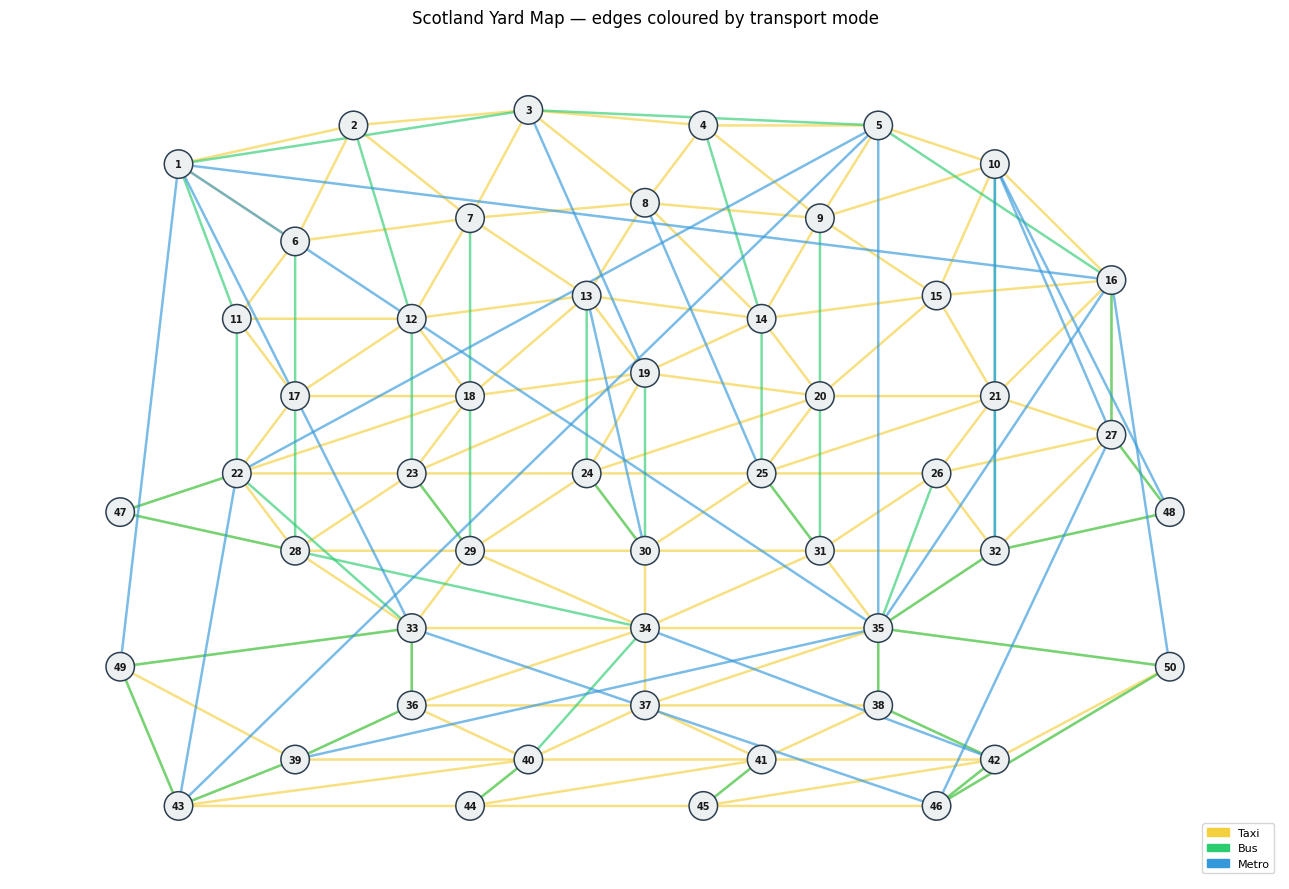

In [3]:
fig, ax = plt.subplots(figsize=(13, 9))
game_map.draw(ax=ax, title='Scotland Yard Map — edges coloured by transport mode')
plt.tight_layout()
plt.show()

---
## 3 — Probabilistic Model: Factors and Transition Matrices

### 3.1 Transition matrices

For each transport mode $m$ we build $T_m \in [0,1]^{N \times N}$:

$$[T_m]_{i,j} = P(x_t = j \mid x_{t-1} = i,\; m_t = m) = \frac{\mathbb{1}[(i,j) \in E_m]}{\deg_m(i)}$$

Each **non-zero row** sums to 1 (uniform over reachable neighbours). A **zero row** means transport $m$ is unavailable from that node — any observation $m_t = m$ would immediately rule out $x_{t-1} = i$.

### 3.2 Observation/capture factor

At each turn, any node occupied by an agent is **impossible** for Mr. X (he would have been caught). This hard constraint is a pointwise factor:

$$\phi_t(x_t) = \prod_{i=1}^n \mathbb{1}[x_t \neq a^i_t] \in \{0, 1\}^N$$

In the factor graph, $\phi_t$ is a **unary factor** connected only to $x_t$ — it does not couple different time steps.

### 3.3 Prior

At $t=0$, agents have no information: $p(x_0) = \text{Uniform}(V)$, i.e. $1/N$ for each node.

In [4]:
TRANSPORTS = ['taxi', 'bus', 'metro']

def build_transition_matrices(gmap, nodes, n2i):
    """
    Build row-stochastic T_m for each transport m.
    T_m[i,j] = P(go to j | at i, using m).  Zero rows = transport unavailable.
    """
    mats = {}
    for m in TRANSPORTS:
        T = np.zeros((N, N))
        for node in nodes:
            nbs = gmap.neighbors(node, m).get(m, [])
            if nbs:
                for nb in nbs:
                    T[n2i[node], n2i[nb]] = 1.0 / len(nbs)
        mats[m] = T
    return mats


def obs_factor(agent_positions: List[int], n2i: Dict, n: int) -> np.ndarray:
    """
    phi_t[i] = 0 if node i is occupied by any agent (capture would occur),
               1 otherwise.
    """
    phi = np.ones(n)
    for pos in agent_positions:
        if pos in n2i:
            phi[n2i[pos]] = 0.0
    return phi


def uniform_prior(n: int) -> np.ndarray:
    return np.ones(n) / n


T_mat = build_transition_matrices(game_map, nodes_sorted, node_to_idx)

print('Transition matrices built:')
for m, T in T_mat.items():
    reachable = (T.sum(axis=1) > 0).sum()
    # sanity: non-zero rows must sum to 1
    bad = T.sum(axis=1)
    bad = bad[(bad > 0) & (np.abs(bad - 1.0) > 1e-10)]
    assert len(bad) == 0, f'Row-stochastic violation in {m}'
    print(f'  {m:5s}  shape={T.shape}  row-stochastic for {reachable}/{N} nodes  ✓')

Transition matrices built:
  taxi   shape=(50, 50)  row-stochastic for 50/50 nodes  ✓
  bus    shape=(50, 50)  row-stochastic for 47/50 nodes  ✓
  metro  shape=(50, 50)  row-stochastic for 23/50 nodes  ✓


---
## 4 -- Sum-Product Algorithm

### 4.1 General formulation (Bishop, Ch. 8)

Given a joint distribution that factorises as

$$p(\mathbf{x}) = \frac{1}{Z} \prod_{s} f_s(\mathbf{x}_s)$$

the **Sum-Product Algorithm** computes all marginals $p(x_i)$ by passing messages along the edges of the factor graph. There are two types of messages.

**Message from a variable node $x$ to a neighbouring factor $f_s$:**

$$\mu_{x \to f_s}(x) = \prod_{f_k \,\in\, \partial x \setminus f_s} \mu_{f_k \to x}(x)$$

the product of all incoming factor-to-variable messages *except* the one from $f_s$ itself. If $x$ has no other neighbours, this message is the constant 1.

**Message from a factor node $f_s$ to a neighbouring variable $x_i$:**

$$\mu_{f_s \to x_i}(x_i) = \sum_{\mathbf{x}_s \setminus x_i} f_s(\mathbf{x}_s) \prod_{x_j \,\in\, \partial f_s \setminus x_i} \mu_{x_j \to f_s}(x_j)$$

the factor is marginalised over all its arguments *except* $x_i$, weighted by all incoming variable-to-factor messages.

The **belief** (normalised marginal) at variable $x_i$ is:

$$b(x_i) \propto \prod_{f_s \,\in\, \partial x_i} \mu_{f_s \to x_i}(x_i)$$

On a **tree-structured** factor graph, one forward and one backward sweep suffice to compute all marginals **exactly**.

### 4.2 Message schedule on our chain

Our factor graph is a chain (tree). The node types are:

```
Variable nodes:  x_0,   x_1,   ...,  x_T
Factor nodes:    phi_0, phi_1, ..., phi_T   (unary, one per turn)
                 f_1,   f_2,   ..., f_T     (binary transition factors)
```

where $\phi_t$ is the unary observation factor connected only to $x_t$, and $f_t$ is the binary transition factor connected to $x_{t-1}$ and $x_t$.

Because the graph is a chain, we can enumerate all messages explicitly.

**Unary factor to variable** (trivial -- no sum, no incoming messages):
$$\mu_{\phi_t \to x_t}(x_t) = \phi_t(x_t)$$

**Variable $x_0$ to factor $f_1$** (left leaf, only $\phi_0$ is its other neighbour):
$$\mu_{x_0 \to f_1}(x_0) = \phi_0(x_0) \cdot p(x_0)$$

**Binary factor $f_t$ to variable $x_t$** (rightward, marginalises over $x_{t-1}$):
$$\mu_{f_t \to x_t}(x_t) = \sum_{x_{t-1}} f_t(x_t, x_{t-1})\; \mu_{x_{t-1} \to f_t}(x_{t-1})$$
Since $f_t(x_t, x_{t-1}) = [T_{m_t}]_{x_{t-1}, x_t}$, this is $T_{m_t}^\top \mu_{x_{t-1} \to f_t}$.

**Variable $x_t$ to factor $f_{t+1}$** (interior node, product of its two other incident messages):
$$\mu_{x_t \to f_{t+1}}(x_t) = \mu_{\phi_t \to x_t}(x_t) \cdot \mu_{f_t \to x_t}(x_t)$$

**Binary factor $f_t$ to variable $x_{t-1}$** (leftward, marginalises over $x_t$):
$$\mu_{f_t \to x_{t-1}}(x_{t-1}) = \sum_{x_t} f_t(x_t, x_{t-1})\; \mu_{x_t \to f_t}(x_t) = T_{m_t} \,\mu_{x_t \to f_t}$$

Collecting rightward messages gives the **forward pass**; collecting leftward messages gives the **backward pass**.

### 4.3 Filtering vs Smoothing

| Mode | Messages used | Belief | When useful |
|------|--------------|--------|-------------|
| **Filtering** | forward only | $b_t(x_t) \propto \mu_{f_t \to x_t} \cdot \phi_t(x_t)$ | online, during the game |
| **Smoothing** | forward + backward | $b_t(x_t) \propto \alpha_t(x_t) \cdot \beta_t(x_t)$ | post-game analysis |

**Complexity:** $O(T \cdot N^2)$ per sweep, or $O(T \cdot N \cdot \bar{d})$ exploiting the sparsity of each $T_m$.

In [ ]:
class SumProduct:
    # Exact Sum-Product on the latent chain  x_0 -- x_1 -- ... -- x_T.
    #
    # Factor graph (bipartite):
    #   (phi_0)-[x_0]-(f_1)-[x_1]-(phi_1)-(f_2)-[x_2]- ... -(f_T)-[x_T]-(phi_T)
    #
    # Variable nodes : x_0, ..., x_T
    # Factor nodes   : phi_0, ..., phi_T   (unary observation factors)
    #                  f_1,  ..., f_T      (binary transition factors)
    #
    # All six message types are stored explicitly, following Bishop Ch. 8.

    def __init__(self, n_nodes: int, trans: Dict[str, np.ndarray]):
        self.N = n_nodes
        self.T = trans   # T[m][i,j] = P(x_t=j | x_{t-1}=i, transport=m)

    # ── Full Sum-Product: both passes ────────────────────────────────

    def run(self,
            prior: np.ndarray,
            transports: List[str],
            phis: List[np.ndarray]) -> Dict[str, list]:
        """
        Run the complete Sum-Product algorithm (forward + backward passes).

        Parameters
        ----------
        prior      : p(x_0),            shape (N,)
        transports : [m_1,...,m_T],      length T
        phis       : [phi_0,...,phi_T],  length T+1, each shape (N,)

        Returns
        -------
        messages : dict with keys:
            mu_phi_to_x : list[T+1]  mu_{phi_t -> x_t}
            mu_x_to_fR  : list[T]    mu_{x_t -> f_{t+1}},   t = 0..T-1
            mu_x_to_fL  : list[T]    mu_{x_t -> f_t},        t = 1..T
            mu_fR_to_x  : list[T]    mu_{f_t -> x_t},        t = 1..T
            mu_fL_to_x  : list[T]    mu_{f_t -> x_{t-1}},   t = 1..T
        """
        T_len = len(transports)
        assert len(phis) == T_len + 1, f'Need {T_len+1} phis, got {len(phis)}'

        # ── Unary messages: phi_t -> x_t  (just phi_t itself) ───────
        # Each observation factor simply sends its local potential to its variable.
        mu_phi_to_x = [phis[t].copy() for t in range(T_len + 1)]

        # ── Forward pass (left -> right) ────────────────────────────
        # We compute two interleaved sequences:
        #   mu_{x_t -> f_{t+1}}  for t = 0..T-1   (stored in mu_x_to_fR)
        #   mu_{f_t -> x_t}      for t = 1..T      (stored in mu_fR_to_x)
        mu_x_to_fR = []
        mu_fR_to_x = []

        #   mu_{x_0 -> f_1}(x_0)  =  norm( phi_0(x_0) · prior(x_0) )
        mu_x_to_fR.append(self._norm(mu_phi_to_x[0]*prior))
        #   Append the result to mu_x_to_fR.
        
        for t in range(1, T_len + 1):
            m = transports[t - 1]

            #   mu_{f_t -> x_t}(x_t)  =  T_m^T  @  mu_{x_{t-1} -> f_t}
            msg_fR = self.T[m].T @ mu_x_to_fR[t-1]
            #   i.e. sum over x_{t-1} of  T_m[x_{t-1}, x_t] · mu_{x_{t-1}->f_t}(x_{t-1})
            #   Append the result to mu_fR_to_x.
            mu_fR_to_x.append(msg_fR)

            if t < T_len:
                # Combine the incoming factor message with the local observation,
                # then pass the result rightward to the next factor.
                #   mu_{x_t -> f_{t+1}}(x_t)  =  norm( phi_t(x_t) · mu_{f_t -> x_t}(x_t) )
                mu_x_to_fR.append(self._norm(mu_phi_to_x[t] * mu_fR_to_x[-1]))

        # ── Backward pass (right -> left) ───────────────────────────
        # Symmetric to the forward pass; now messages travel from right to left.
        #   mu_{x_t -> f_t}     for t = 1..T   (stored in mu_x_to_fL)
        #   mu_{f_t -> x_{t-1}} for t = 1..T   (stored in mu_fL_to_x)
        mu_x_to_fL = [None] * T_len
        mu_fL_to_x = [None] * T_len

        #   mu_{x_T -> f_T}(x_T)  =  norm( phi_T(x_T) )
        #   x_T has only one other neighbour: phi_T.  No transition message arrives from the right.
        #   Hint: normalise mu_phi_to_x[T_len] and store in mu_x_to_fL[T_len - 1].
        mu_x_to_fL[T_len-1] = self._norm(mu_phi_to_x[T_len])
        
        for t in range(T_len - 1, 0, -1):
            m = transports[t]

            #   Step A – factor message arriving at x_t from the right:
            #     mu_{f_{t+1} -> x_t}(x_t)  =  T_m  @  mu_{x_{t+1} -> f_{t+1}}
            #     i.e. sum over x_{t+1} of  T_m[x_t, x_{t+1}] · mu_{x_{t+1}->f_{t+1}}(x_{t+1})
            msg_fL = self.T[m] @ mu_x_to_fL[t]
            #     Store the result in mu_fL_to_x[t].
            mu_fL_to_x[t] = msg_fL

            #   Step B – variable message leaving x_t toward the left:
            #     mu_{x_t -> f_t}(x_t)  =  norm( phi_t(x_t) · mu_{f_{t+1} -> x_t}(x_t) )
            mu_x_to_fL[t-1] = self._norm(mu_phi_to_x[t]*msg_fL)

        # Leftward message from f_1 all the way to the left leaf x_0
        # (no further variable-to-factor message is needed for x_0 in this direction).
        mu_fL_to_x[0] = self.T[transports[0]] @ mu_x_to_fL[0]

        return {
            'mu_phi_to_x': mu_phi_to_x,
            'mu_x_to_fR':  mu_x_to_fR,
            'mu_x_to_fL':  mu_x_to_fL,
            'mu_fR_to_x':  mu_fR_to_x,
            'mu_fL_to_x':  mu_fL_to_x,
        }

    # ── Beliefs from messages ────────────────────────────────────────

    def beliefs_from_messages(self,
                               prior: np.ndarray,
                               messages: Dict[str, list]) -> List[np.ndarray]:
        """
        Compute the normalised belief b(x_t) at every node from stored messages.

        The belief is proportional to the product of ALL factor->variable messages
        incident on x_t:

          x_0      :  prior · mu_{phi_0->x_0} · mu_{f_1->x_0}
          0 < t < T:  mu_{phi_t->x_t} · mu_{f_t->x_t} · mu_{f_{t+1}->x_t}
          x_T      :  mu_{phi_T->x_T} · mu_{f_T->x_T}

        Parameters
        ----------
        prior    : p(x_0), shape (N,)
        messages : output of run()

        Returns
        -------
        beliefs : list[T+1] of normalised arrays, each shape (N,)
        """
        T_len = len(messages['mu_fR_to_x'])
        beliefs = []

        # Belief at the left leaf x_0.
        #   Multiply prior, mu_phi_to_x[0], and mu_fL_to_x[0] element-wise,
        #   normalise, and append to beliefs.
        b = prior * messages['mu_phi_to_x'][0] * messages['mu_fL_to_x'][0]
        beliefs.append(self._norm(b))

        for t in range(1, T_len):
            # Belief at an interior node x_t  (0 < t < T).
            #   Three incoming messages: mu_phi_to_x[t], mu_fR_to_x[t-1], mu_fL_to_x[t].
            #   Multiply them element-wise, normalise, and append to beliefs.
            b = (messages['mu_phi_to_x'][t] * messages['mu_fR_to_x'][t-1] * messages['mu_fL_to_x'][t])
            beliefs.append(self._norm(b))

        # Belief at the right leaf x_T.
        #   Two incoming messages: mu_phi_to_x[T_len] and mu_fR_to_x[T_len - 1].
        #   Multiply element-wise, normalise, and append to beliefs.
        b = (messages['mu_phi_to_x'][T_len] * messages['mu_fR_to_x'][T_len-1])
        beliefs.append(self._norm(b))

        return beliefs

    # ── Convenience wrappers ─────────────────────────────────────────

    def smoothed_beliefs(self,
                          prior: np.ndarray,
                          transports: List[str],
                          phis: List[np.ndarray]) -> List[np.ndarray]:
        """Full forward-backward: smoothed beliefs at every turn."""
        msgs = self.run(prior, transports, phis)
        return self.beliefs_from_messages(prior, msgs)

    def filter_belief(self,
                       prior: np.ndarray,
                       transports: List[str],
                       phis: List[np.ndarray]) -> np.ndarray:
        """
        Online filtered belief at the latest turn using only the forward pass.

        Because there is no future evidence, all backward messages are uniform (≡ 1),
        so the filtered belief at x_T reduces to:

            b(x_T)  ∝  phi_T(x_T) · mu_{f_T -> x_T}(x_T)

        which is exactly the last message produced by the forward sweep.

        Parameters
        ----------
        prior      : p(x_0),            shape (N,)
        transports : [m_1,...,m_T],      length T
        phis       : [phi_0,...,phi_T],  length T+1

        Returns
        -------
        belief : normalised array, shape (N,)
        """
        assert len(phis) == len(transports) + 1

        # Implement the forward-only sweep.
        #   1. Initialise msg = norm( phis[0] · prior )          ← left-leaf seed
        msg = self._norm(phis[0] * prior)
        #   2. For each (t, m) in enumerate(transports):
        for t, m in enumerate(transports):
        #        a. msg_f = self.T[m].T @ msg                    ← factor message
            msg_f = self.T[m].T @ msg
        #        b. msg   = norm( phis[t+1] · msg_f )            ← absorb observation
            msg = self._norm(phis[t+1] * msg_f)
        #   3. Return msg.
        return msg

    @staticmethod
    def _norm(v: np.ndarray) -> np.ndarray:
        s = v.sum()
        return v / s if s > 1e-300 else np.ones_like(v) / len(v)


sp = SumProduct(N, T_mat)
print(f'SumProduct ready. State space: {N} nodes.')

# ── Sanity check (run this after completing all TODOs) ───────────────────────
# On a 1-step chain with no evidence, smoothed[-1] must equal filtered.
_p  = uniform_prior(N)
_ph = [np.ones(N), np.ones(N)]
_tr = ['taxi']
assert np.allclose(sp.smoothed_beliefs(_p, _tr, _ph)[-1],
                   sp.filter_belief(_p, _tr, _ph), atol=1e-10), \
    'Sanity check FAILED — double-check your forward pass and filter_belief.'
print('Sanity check passed: smoothed[-1] == filtered on a 1-step chain.')

SumProduct ready. State space: 50 nodes.
Sanity check passed: smoothed[-1] == filtered on a 1-step chain.


---
## 5 — Game Simulation

We simulate a full game. At each turn:
1. Mr. X moves *first* (random strategy) and reveals only the transport type.
2. Agents update the **filtered belief** via one forward-pass step of Sum-Product.
3. Agents move **greedily** toward the neighbour with *highest belief*.

In [6]:
# ════════════════════════════════════════
#  PARAMETERS  —  change these!
# ════════════════════════════════════════
N_AGENTS = 3     # try 1..5  (map now has 51 nodes!)  (map now has 50 nodes!)
N_TURNS  = 10
# ════════════════════════════════════════

print(f'Settings:  {N_AGENTS} agent(s),  {N_TURNS} turns')

Settings:  3 agent(s),  10 turns


In [11]:
class MrX:
    """
    Hidden player. Only the transport used each turn is revealed.

    Attributes
    ----------
    pos               : current (hidden) position node
    gmap              : ScotlandYardMap used to query neighbours
    pos_history       : full list of positions visited, starting from start
    transport_history : list of transport modes used, one per move
    """

    def __init__(self, start: int, gmap: ScotlandYardMap):
      self.pos = start
      self.gmap = gmap
      self.pos_history: List[int] = [start]
      self.transport_history: List[int] = []

    def move(self) -> str:
        """
        Execute one move using a random strategy and return the transport used.

        Strategy
        --------
        1. Query the map for all neighbours of the current position.
           Result: a dict  { transport_mode: [dest, dest, ...], ... }
        2. If no neighbours exist (Mr X is trapped), fall back to 'taxi'
           and do NOT change position.
        3. Otherwise, pick a transport mode uniformly at random from the
           available modes, then pick a destination uniformly at random
           from the destinations reachable by that mode.
        4. Update pos, pos_history, and transport_history accordingly.
        5. Return the transport mode string (this is the only information
           revealed to the detectives).

        Returns
        -------
        transport : str   e.g. 'taxi', 'bus', 'underground'
        """
        nb = self.gmap.neighbors(self.pos)

        # Handle the trapped case.
        #   If nb is empty, append 'taxi' to transport_history and return 'taxi'.
        #   Do NOT update pos or pos_history.
        if not nb:
         self.transport_history.append('taxi')
         return 'taxi'

        # Sample a transport mode uniformly at random.
        #   Hint: nb.keys() gives the available modes; use np.random.choice
        #   on a list of those keys.
        m = np.random.choice(list(nb.keys()))

        # Sample a destination for the chosen mode.
        #   Hint: nb[m] is the list of reachable nodes under mode m.
        dest = np.random.choice(nb[m])

        # Commit the move.
        #   Update self.pos, append to self.pos_history, append to
        #   self.transport_history, and return the transport mode string.
        self.pos = dest
        self.pos_history.append(dest)
        self.transport_history.append(m)

        return m

In [12]:
class RandomicAgent:
    """
    Detective agent with a random strategy: move to any neighbour uniformly.

    Attributes
    ----------
    id          : unique integer identifier for this detective
    pos         : current position node
    gmap        : ScotlandYardMap used to query neighbours
    pos_history : list of positions visited, starting from start
    """

    def __init__(self, agent_id: int, start: int, gmap: ScotlandYardMap):
        #   store agent_id as self.id, position, map, and initialise
        #   pos_history with [start].  No transport_history needed here.
        self.pos = start
        self.id = agent_id
        self.gmap = gmap
        self.pos_history: List[int] = [start]

    def move(self, belief: np.ndarray):
        """
        Execute one move and update position in-place.

        Strategy
        --------
        Flatten all reachable neighbours across every transport mode into a
        single list, then pick one uniformly at random.
        If no neighbours exist, stay in place (append current pos and return).

        Parameters
        ----------
        belief : current probability distribution over Mr X's position (not
                 used by this agent, but present for interface consistency
                 with belief-based agents you will implement later).
        """
        # Flatten all neighbours across transport types into one list.
        nb = [v for vs in self.gmap.neighbors(self.pos).values() for v in vs]

        # Handle the trapped case.
        #   If nb is empty, append self.pos to pos_history and return early.
        #   Identical pattern to MrX: no position change, just record and exit.
        if not nb:
            self.pos_history.append(self.pos)
            return

        # Sample a destination and commit the move.
        #   Pick one node from nb uniformly at random (cast to int).
        #   Update self.pos and append the new position to pos_history.
        self.pos = int(np.random.choice(nb))
        self.pos_history.append(self.pos)

In [13]:
def entropy(p: np.ndarray) -> float:
    """Measures uncertainty: lower values mean the detectives are closing in."""
    q = p[p > 1e-12]
    return float(-np.sum(q * np.log2(q)))

In [14]:
class GreedyAgent:
    """
    Detective agent with a greedy strategy: move to the neighbour with the
    highest belief probability.

    Attributes
    ----------
    id          : unique integer identifier for this detective
    pos         : current position node
    gmap        : ScotlandYardMap used to query neighbours
    pos_history : list of positions visited, starting from start
    """

    def __init__(self, agent_id: int, start: int, gmap: ScotlandYardMap):
        self.pos = start
        self.id = agent_id
        self.gmap = gmap
        self.pos_history: List[int] = [start]

    def move(self, belief: np.ndarray, node_to_idx: Dict[int, int]):
        """
        Execute one move toward the most likely position of Mr X.

        Strategy
        --------
        1. Collect all unique reachable neighbours (across all transport modes).
        2. If none exist, stay in place.
        3. Otherwise, pick the neighbour v that maximises belief[node_to_idx[v]]
           and move there.

        Parameters
        ----------
        belief      : current probability distribution over Mr X's position,
                      shape (N,) indexed by the model's internal state index.
        node_to_idx : mapping from map node id  ->  belief-vector index.
        """
        # Deduplicated neighbour list across all transport modes.
        nb = list(set(v for vs in self.gmap.neighbors(self.pos).values() for v in vs))

        # Handle the trapped case.
        #   Same pattern as RandomicAgent: append self.pos and return early.
        if not nb:
            self.pos_history.append(self.pos)
            return

        # Pick the best neighbour!
        #   Use max() over nb with a key that looks up belief[node_to_idx[v]].
        best = max(nb, key=lambda v: belief[node_to_idx[v]])

        # Commit the move.
        #   Update self.pos to best and append it to pos_history.
        self.pos = best
        self.pos_history.append(best)

In [15]:
def run_game(n_agents: int, n_turns: int, strategy: str = 'greedy', verbose: bool = True, seed: int = 42):
    """
    Simulate a Scotland Yard game with Sum-Product inference.

    Parameters
    ----------
    strategy : 'greedy' or 'randomic'
    """
    rng = np.random.RandomState(seed)
    # Ensure we use the same seed for starting positions to keep comparisons fair
    starts = rng.choice(nodes_sorted, size=n_agents + 1, replace=False)

    mrx = MrX(int(starts[0]), game_map)
    
    # Initialize agents based on chosen strategy
    if strategy.lower() == 'greedy':
        agents = [GreedyAgent(i, int(starts[i+1]), game_map) for i in range(n_agents)]
    else:
        agents = [RandomicAgent(i, int(starts[i+1]), game_map) for i in range(n_agents)]

    prior = uniform_prior(N)
    transport_seq: List[str]          = []
    phis:          List[np.ndarray]   = []
    filter_beliefs: List[np.ndarray]  = []

    # t = 0: initial belief
    phis.append(obs_factor([a.pos for a in agents], node_to_idx, N))
    filter_beliefs.append(sp._norm(prior * phis[0]))

    if verbose:
            print(f"\n--- Starting Game: Strategy={strategy.upper()}, Agents={n_agents} ---")
            hdr = f"{'Turn':>4} | {'Transport':>9} | {'Mr.X pos':>8} | " \
                  + f"{'H(b) bit':>8} | {'argmax b':>8} | {'P(true)':>8} | Status"
            print(hdr)
            print('─' * 85)

    captured, capture_turn = False, None

    for turn in range(1, n_turns + 1):
        # Step 1 — Mr. X moves
        m = mrx.move()
        transport_seq.append(m)

        # Step 2 — Update belief (Sum-Product forward pass)
        phis.append(obs_factor([a.pos for a in agents], node_to_idx, N))
        belief = sp.filter_belief(prior, transport_seq, phis)
        filter_beliefs.append(belief.copy())

        # Step 3 — Agents move based on strategy
        for a in agents:
            if isinstance(a, GreedyAgent):
                a.move(belief, node_to_idx)
            else:
                a.move(belief) # RandomicAgent ignores the belief but accepts the arg

        # Step 4 — Capture check
        if mrx.pos in [a.pos for a in agents]:
            captured, capture_turn = True, turn

        if verbose:
            h   = entropy(belief)
            am  = nodes_sorted[int(np.argmax(belief))]
            p_t = float(belief[node_to_idx[mrx.pos]])
            flag = '  <- CAUGHT!' if (captured and capture_turn == turn) else ''
            print(f'{turn:>4} | {m:>9} | {mrx.pos:>8} | '
                  f'{h:>8.3f} | {am:>8} | {p_t:>8.4f} |{flag}')

        if captured:
            break

    return filter_beliefs, mrx, agents, captured, capture_turn

In [21]:
# --- Evaluation Execution ---

# 1. Run Greedy Scenario
res_g = run_game(N_AGENTS, N_TURNS, strategy='greedy', seed=42)

# 2. Run Randomic Scenario
res_r = run_game(N_AGENTS, N_TURNS, strategy='randomic', seed=42)

# Quick summary comparison
print(f"\nSummary:")
print(f"Greedy Result:   Captured={res_g[3]} at turn {res_g[4]}")
print(f"Randomic Result: Captured={res_r[3]} at turn {res_r[4]}")


--- Starting Game: Strategy=GREEDY, Agents=3 ---
Turn | Transport | Mr.X pos | H(b) bit | argmax b |  P(true) | Status
─────────────────────────────────────────────────────────────────────────────────────
   1 |      taxi |       15 |    5.499 |        9 |   0.0266 |
   2 |      taxi |       16 |    5.498 |        7 |   0.0214 |
   3 |      taxi |       10 |    5.461 |        7 |   0.0220 |
   4 |      taxi |       15 |    5.468 |        7 |   0.0000 |
   5 |      taxi |       20 |    5.476 |        8 |   0.0248 |
   6 |      taxi |       14 |    5.518 |        7 |   0.0271 |
   7 |      taxi |        8 |    5.559 |        8 |   0.0335 |  <- CAUGHT!

--- Starting Game: Strategy=RANDOMIC, Agents=3 ---
Turn | Transport | Mr.X pos | H(b) bit | argmax b |  P(true) | Status
─────────────────────────────────────────────────────────────────────────────────────
   1 |       bus |        4 |    5.275 |       35 |   0.0123 |
   2 |      taxi |        8 |    5.450 |       22 |   0.0231 |
   3 | 

### 5.1 Visualise the belief on the map

In [18]:
def plot_belief_sequence(filter_beliefs, mrx, agents, strategy_name="Greedy", n_show=4):
    """
    Plot the map with belief heat for the first n_show turns.
    Added strategy_name to differentiate between evaluation runs.
    """
    n_show = min(n_show, len(filter_beliefs))
    fig, axes = plt.subplots(1, n_show, figsize=(5.5 * n_show, 6.5))
    if n_show == 1:
        axes = [axes]

    for ti, ax in enumerate(axes):
        belief  = filter_beliefs[ti]

        # Get historical positions at time ti
        mrx_pos = mrx.pos_history[ti] if ti < len(mrx.pos_history) else None
        ag_pos  = [a.pos_history[ti] for a in agents if ti < len(a.pos_history)]

        # Construct informative title
        title = f'Turn {ti}'
        if ti > 0 and ti - 1 < len(mrx.transport_history):
            title += f' | {mrx.transport_history[ti-1]}'
        title += f'\nH = {entropy(belief):.2f} bit'

        # Render the map
        game_map.draw(
            ax=ax,
            node_belief=belief,
            highlight={'mrx': ([mrx_pos] if mrx_pos else []), 'agents': ag_pos},
            title=title,
        )

        # ── Per-panel reading guide (bottom of each subplot) ────────────────
        # Placed as a figure-text anchored in axes coordinates so it stays
        # below the map regardless of node layout.
        legend_lines = [
            '■ bright yellow  →  high P(Mr X here)',
            '■ dark purple    →  low / zero belief',
            '● red            →  Mr X true position',
            '● purple         →  detective(s)',
            'H = Shannon entropy of belief (bits)',
            '   low H  →  belief concentrated (certain)',
            '   high H →  belief spread (uncertain)',
        ]
        ax.text(
            0.01, -0.04,
            '\n'.join(legend_lines),
            transform=ax.transAxes,
            fontsize=7.5,
            verticalalignment='top',
            fontfamily='monospace',
            color='#444444',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f7f7f7',
                      edgecolor='#cccccc', linewidth=0.6),
        )

        # ── Turn-specific annotation: entropy interpretation ─────────────────
        H = entropy(belief)
        if H < 1.5:
            interp = 'Belief tightly concentrated — detectives close!'
        elif H < 3.5:
            interp = 'Moderate uncertainty — a few candidate areas.'
        else:
            interp = 'High uncertainty — Mr X could be anywhere.'

        ax.text(
            0.99, -0.04,
            interp,
            transform=ax.transAxes,
            fontsize=7.5,
            verticalalignment='top',
            horizontalalignment='right',
            style='italic',
            color='#555555',
        )

    plt.suptitle(
        f'Strategy: {strategy_name.upper()} | Filtered belief heatmap\n'
        'Red = Mr X true position  |  Purple = Detectives  |  '
        'Colour intensity = P(Mr X at node)',
        fontsize=12, y=1.02, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()

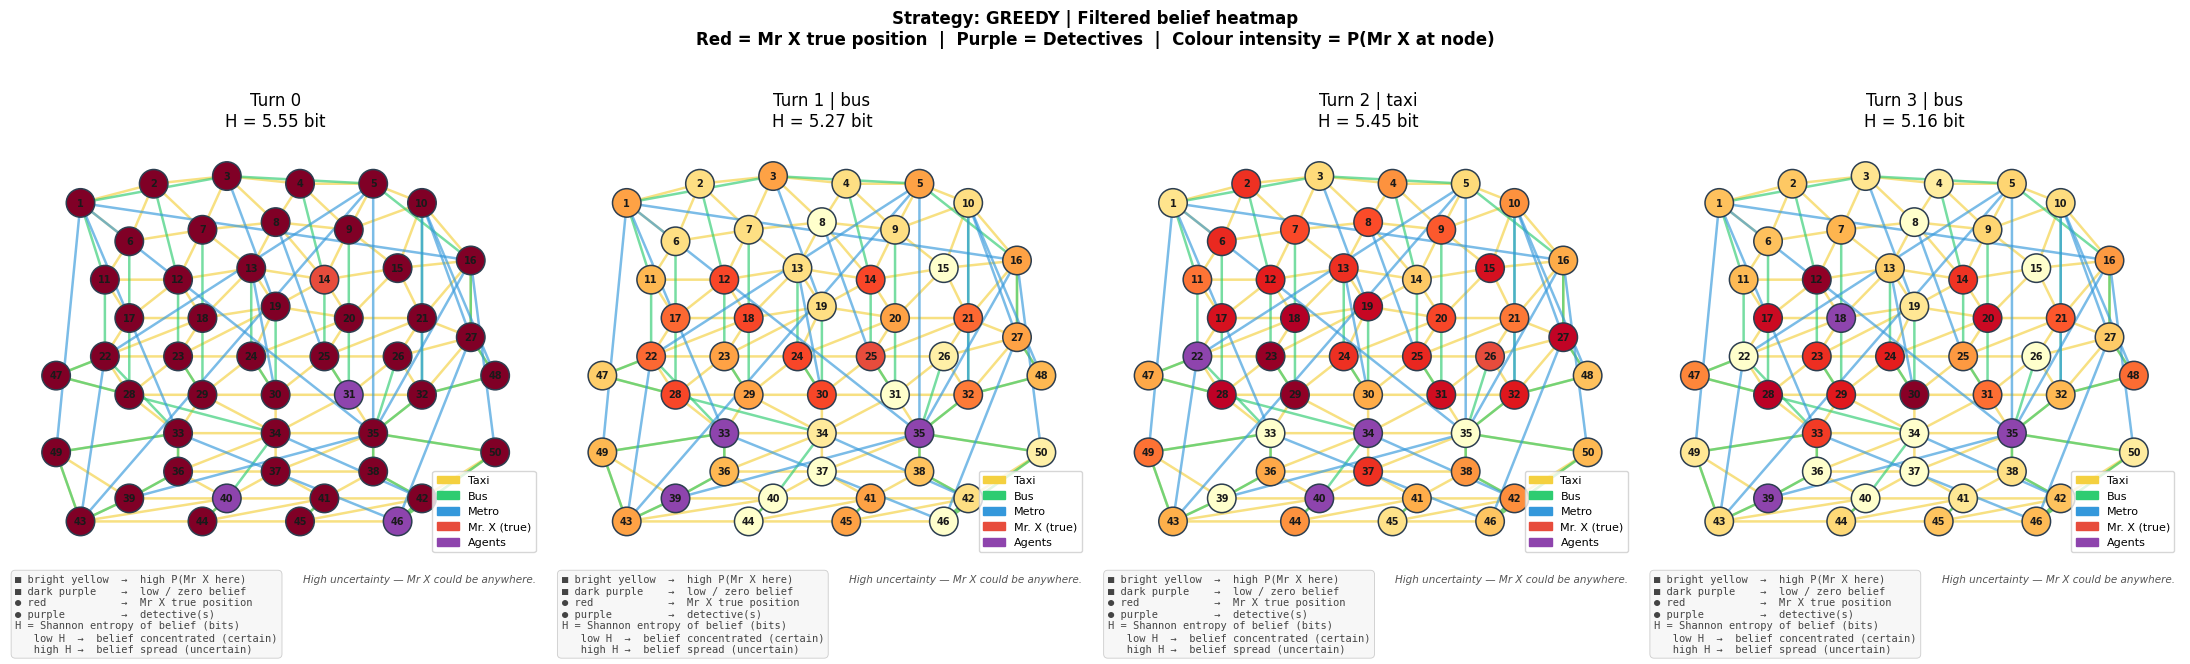

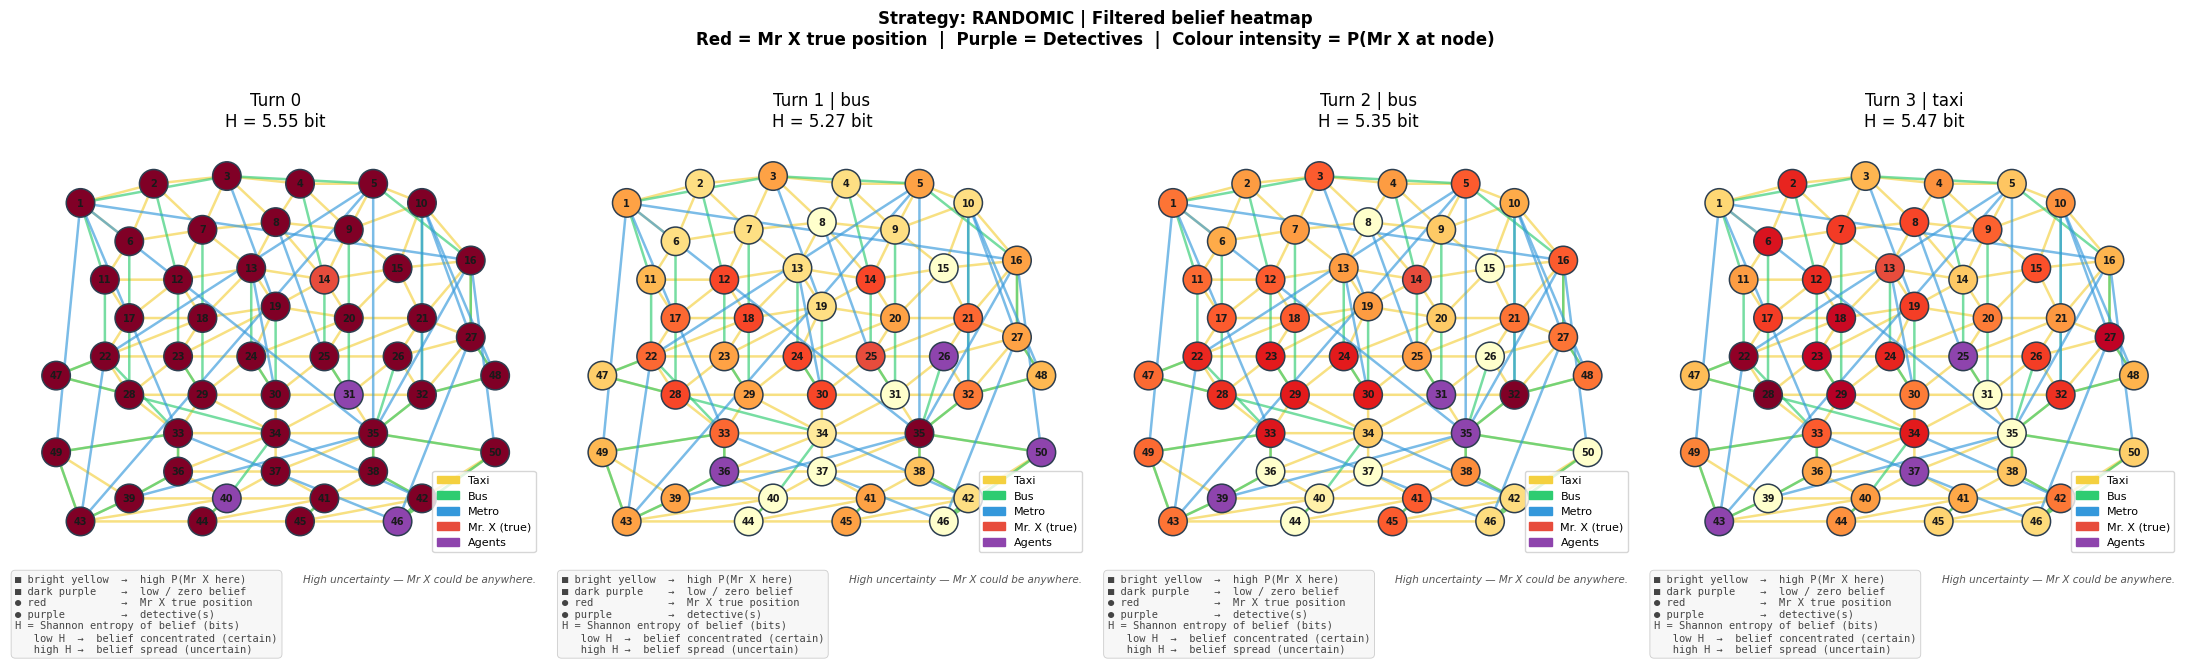

In [19]:
# --- Visual Evaluation ---

# Plot the first 4 turns of the Greedy run
plot_belief_sequence(res_g[0], res_g[1], res_g[2], strategy_name="Greedy", n_show=4)

# Plot the first 4 turns of the Randomic run
plot_belief_sequence(res_r[0], res_r[1], res_r[2], strategy_name="Randomic", n_show=4)

### 5.2 Entropy as a measure of prediction confidence

Before plotting the belief evolution, we need a scalar that captures how *concentrated* -- and therefore how *useful* -- the belief is. Shannon entropy is the natural choice.

#### Definition (Bishop, Ch. 1)

The **entropy** of a discrete distribution $p$ over a finite set $\mathcal{X}$ is:

$$H[p] = -\sum_{x \in \mathcal{X}} p(x) \log_2 p(x)$$

measured in **bits**. It satisfies two key properties:

1. **Maximum at uniformity.** $H[p] \le \log_2 |\mathcal{X}|$, with equality iff $p$ is uniform. Here $H_{\max} = \log_2 N$ bits -- the entropy when the agents know absolutely nothing about Mr. X's position.

2. **Zero at certainty.** $H[p] = 0$ iff $p$ is a point mass. Complete knowledge of Mr. X's location corresponds to zero entropy.

#### Why entropy as a proxy for quality of the belief?

After running Sum-Product we have a belief vector $b_t \in \Delta^{N-1}$. We want a single scalar that answers: *how well localised is Mr. X in the agents' model?* Entropy provides exactly this:

- **High $H[b_t]$** $\to$ belief spread over many nodes $\to$ Mr. X is hard to find.
- **Low $H[b_t]$** $\to$ belief concentrated on few nodes $\to$ agents know where to look.

This is not just intuition. By Shannon's source coding theorem, $H[b_t]$ equals the **expected minimum number of binary questions** needed to identify Mr. X's node under the belief $b_t$. Equivalently, it is the **expected log-loss**: $H[b_t] = \mathbb{E}_{x \sim b_t}[-\log_2 b_t(x)]$. Both interpretations make entropy the canonical scalar measure of uncertainty in a discrete inference problem.

In the plots below we track $H[b_t]$ alongside $b_t(x_t^{*})$ -- the probability mass placed on the **true** position of Mr. X -- to assess inference quality from both directions simultaneously.

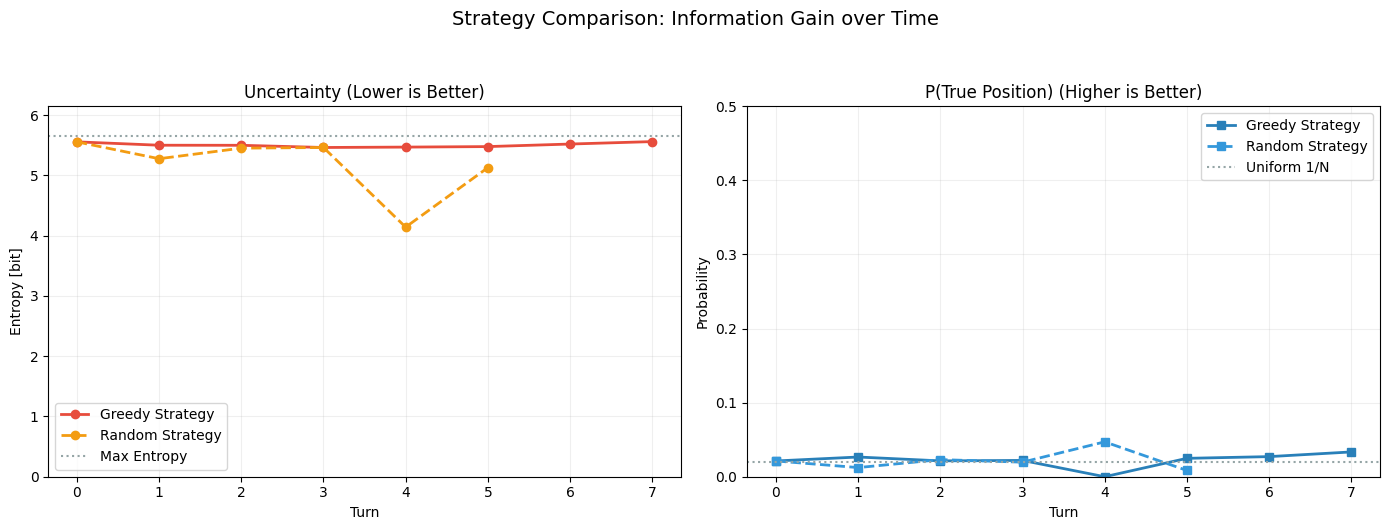

Metric               | Greedy     | Randomic  
----------------------------------------------
Final Entropy        | 5.559 bit | 5.126 bit
Information Gained   | -0.004 bit | 0.428 bit


In [22]:
def plot_comparative_metrics(res_g, res_r):
    """
    Plot Entropy and True Position Probability for both strategies.
    res_g: Result from run_game(strategy='greedy')
    res_r: Result from run_game(strategy='randomic')
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Data extraction for Greedy
    beliefs_g, mrx_g, _, _, _ = res_g
    ents_g = [entropy(b) for b in beliefs_g]
    probs_g = [float(beliefs_g[t][node_to_idx[mrx_g.pos_history[t]]]) 
               for t in range(len(beliefs_g))]

    # Data extraction for Randomic
    beliefs_r, mrx_r, _, _, _ = res_r
    ents_r = [entropy(b) for b in beliefs_r]
    probs_r = [float(beliefs_r[t][node_to_idx[mrx_r.pos_history[t]]]) 
               for t in range(len(beliefs_r))]

    # --- Plot 1: Entropy (Uncertainty) ---
    ax1.plot(ents_g, 'o-', color='#E74C3C', label='Greedy Strategy', lw=2)
    ax1.plot(ents_r, 'o--', color='#F39C12', label='Random Strategy', lw=2)
    ax1.axhline(np.log2(N), color='#95A5A6', ls=':', label='Max Entropy')
    ax1.set_xlabel('Turn')
    ax1.set_ylabel('Entropy [bit]')
    ax1.set_title('Uncertainty (Lower is Better)')
    ax1.set_ylim(0, np.log2(N) + 0.5)
    ax1.legend()
    ax1.grid(alpha=0.2)

    # --- Plot 2: Probability of True Position (Confidence) ---
    ax2.plot(probs_g, 's-', color='#2980B9', label='Greedy Strategy', lw=2)
    ax2.plot(probs_r, 's--', color='#3498DB', label='Random Strategy', lw=2)
    ax2.axhline(1.0/N, color='#95A5A6', ls=':', label='Uniform 1/N')
    ax2.set_xlabel('Turn')
    ax2.set_ylabel('Probability')
    ax2.set_title('P(True Position) (Higher is Better)')
    ax2.set_ylim(0, 0.5)
    ax2.legend()
    ax2.grid(alpha=0.2)

    plt.suptitle('Strategy Comparison: Information Gain over Time', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

    # Print Information Gain Summary
    print(f"{'Metric':<20} | {'Greedy':<10} | {'Randomic':<10}")
    print("-" * 46)
    print(f"{'Final Entropy':<20} | {ents_g[-1]:.3f} bit | {ents_r[-1]:.3f} bit")
    print(f"{'Information Gained':<20} | {ents_g[0]-ents_g[-1]:.3f} bit | {ents_r[0]-ents_r[-1]:.3f} bit")

# Execute
plot_comparative_metrics(res_g, res_r)

---
## 6 — Smoothing: Forward-Backward vs Forward-Only

**Filtered** belief $\alpha_t$ only uses evidence up to turn $t$.
**Smoothed** belief $\alpha_t \cdot \beta_t$ uses the entire trajectory $0 \ldots T$.

Note that at the **final turn** $T$, $\beta_T = \mathbf{1}$, so filtered = smoothed. Smoothing provides the greatest gain at **early turns**, where future evidence has not yet been incorporated.

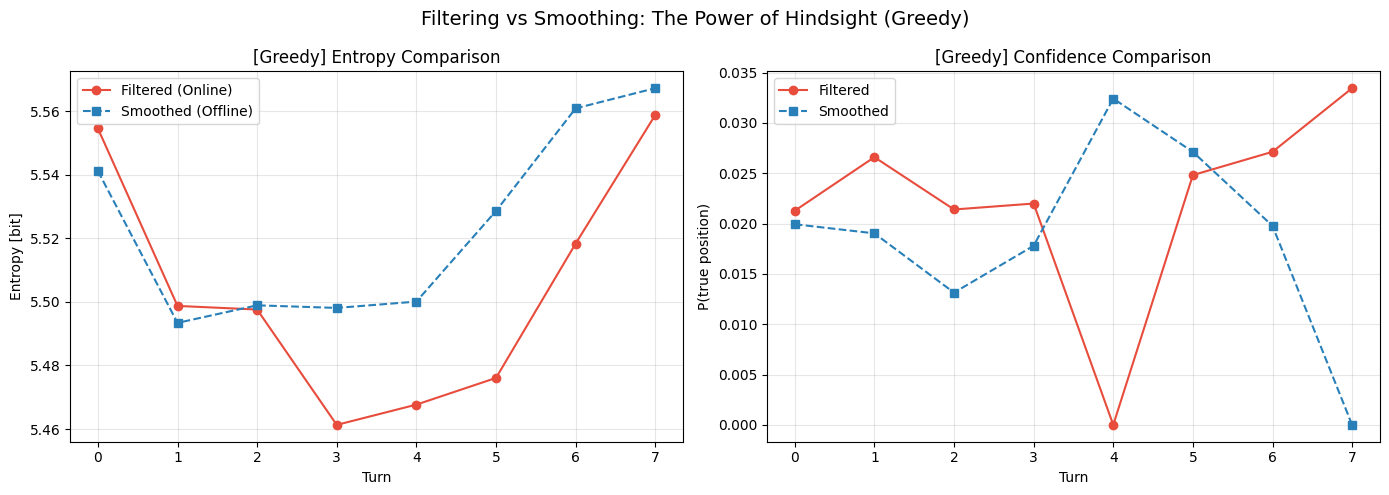

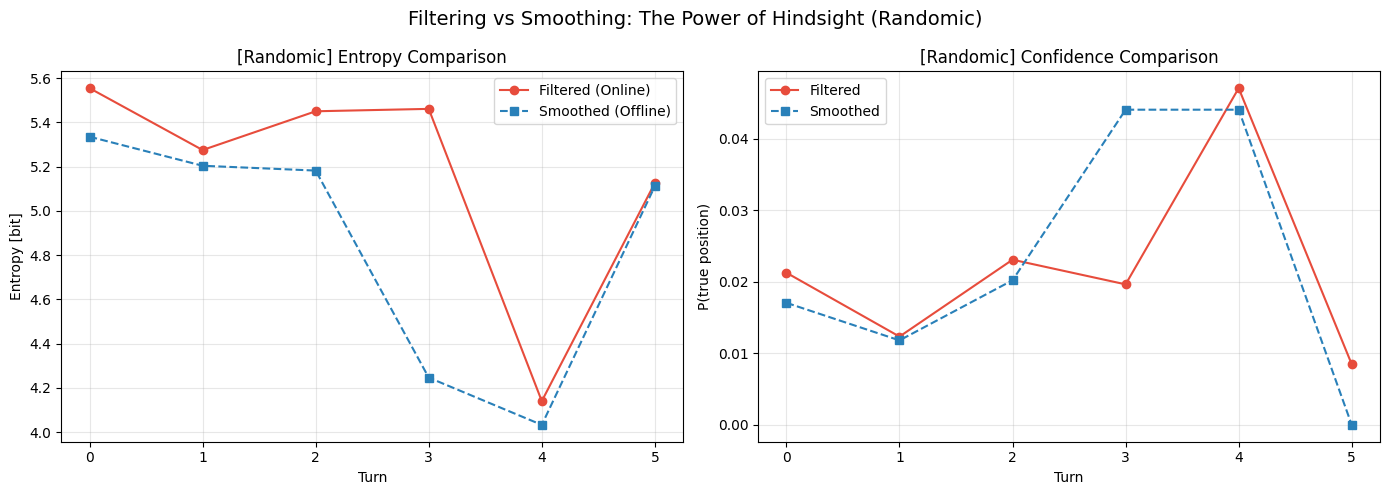

In [23]:
def plot_smoothing_comparison(res, strategy_name="Greedy"):
    """
    Evaluates how much 'Smoothing' helps over 'Filtering' for a specific run.
    """
    filter_beliefs, mrx, agents, _, _ = res
    N = len(filter_beliefs[0])
    
    # 1. Reconstruct parameters from game history
    # Turn 0 phis + phis for every move made
    phis_full = [obs_factor([a.pos_history[0] for a in agents], node_to_idx, N)]
    for t in range(1, len(mrx.transport_history) + 1):
        # Detective positions at turn t
        ag_at_t = [a.pos_history[min(t, len(a.pos_history)-1)] for a in agents]
        phis_full.append(obs_factor(ag_at_t, node_to_idx, N))

    # 2. Run the Full Sum-Product (Backward Pass included)
    # Using the smoothed_beliefs wrapper from your SumProduct class
    smooth_beliefs = sp.smoothed_beliefs(uniform_prior(N), mrx.transport_history, phis_full)

    # 3. Calculate Metrics
    # Entropy (Uncertainty)
    ent_f = [entropy(b) for b in filter_beliefs]
    ent_s = [entropy(b) for b in smooth_beliefs]

    # Confidence (P at true position)
    pt_f = [float(filter_beliefs[t][node_to_idx[mrx.pos_history[t]]]) 
            for t in range(len(filter_beliefs))]
    pt_s = [float(smooth_beliefs[t][node_to_idx[mrx.pos_history[t]]]) 
            for t in range(len(smooth_beliefs))]

    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Entropy
    ax1.plot(ent_f, 'o-',  color='#E74C3C', label='Filtered (Online)')
    ax1.plot(ent_s, 's--', color='#2980B9', label='Smoothed (Offline)')
    ax1.set_title(f'[{strategy_name}] Entropy Comparison')
    ax1.set_xlabel('Turn'); ax1.set_ylabel('Entropy [bit]')
    ax1.legend(); ax1.grid(alpha=0.3)

    # Plot P(True Pos)
    ax2.plot(pt_f, 'o-',  color='#E74C3C', label='Filtered')
    ax2.plot(pt_s, 's--', color='#2980B9', label='Smoothed')
    ax2.set_title(f'[{strategy_name}] Confidence Comparison')
    ax2.set_xlabel('Turn'); ax2.set_ylabel('P(true position)')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(f'Filtering vs Smoothing: The Power of Hindsight ({strategy_name})', fontsize=14)
    plt.tight_layout()
    plt.show()

# Run for both scenarios
plot_smoothing_comparison(res_g, "Greedy")
plot_smoothing_comparison(res_r, "Randomic")

---
## 7 — Influence of the Number of Agents

More agents $\Rightarrow$ more occupied nodes $\Rightarrow$ larger zero-regions in $\phi_t$ $\Rightarrow$ faster belief concentration.

Below we run the game for $n = 1, 2, 3, 4, 5$ agents and compare inference quality.

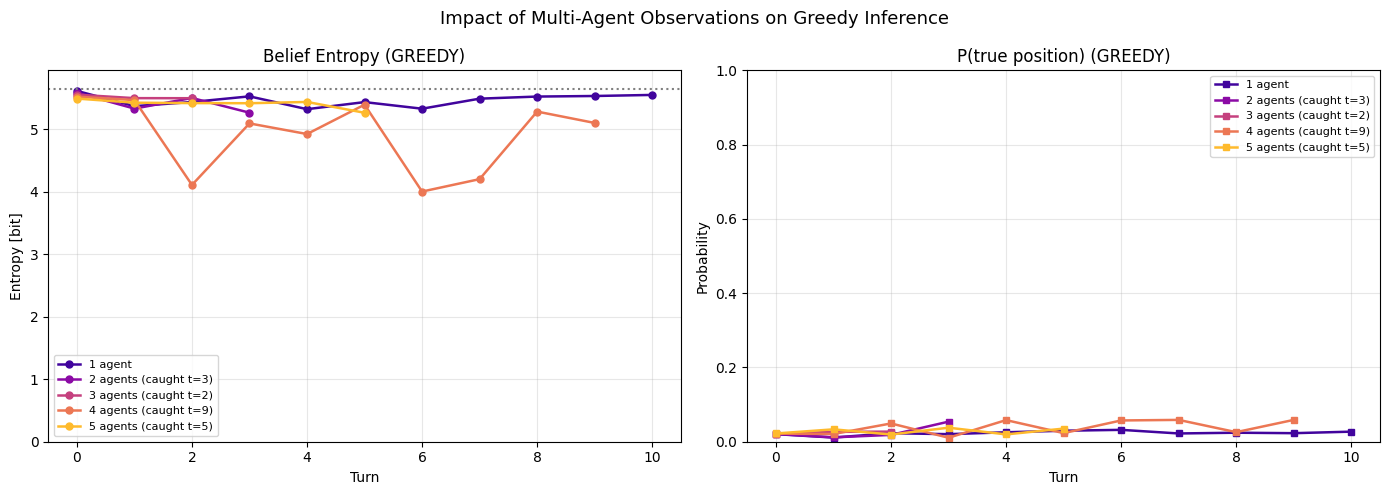

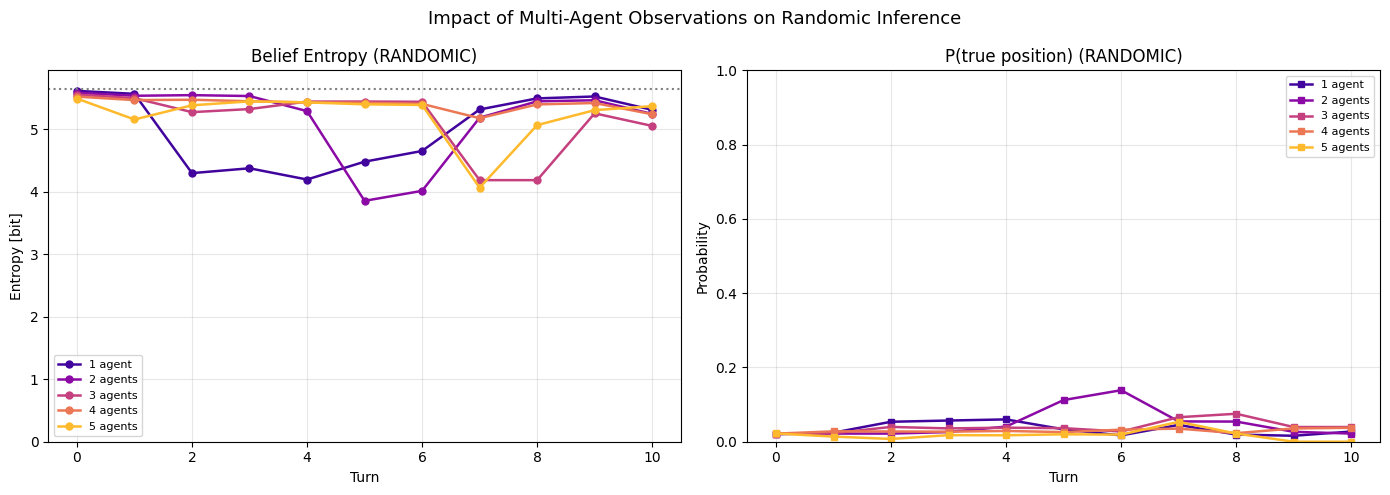

In [26]:
def plot_agent_scaling(strategy='greedy', seed=42):
    """
    Evaluates how the number of agents (1 to 5) affects the game 
    under a specific movement strategy.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.plasma(np.linspace(0.1, 0.85, 5))
    
    # Test agent counts from 1 to 5
    agent_counts = [1, 2, 3, 4, 5]

    for k, n_ag in enumerate(agent_counts):
        # Run game using the specified strategy
        fb, mx, ag, cap, ct = run_game(
            n_agents=n_ag, 
            n_turns=N_TURNS, 
            strategy=strategy,
            verbose=False, 
            seed=seed
        )
        
        ents = [entropy(b) for b in fb]
        pt   = [float(fb[t][node_to_idx[mx.pos_history[t]]]) 
                for t in range(min(len(fb), len(mx.pos_history)))]
        
        lbl = f'{n_ag} agent' + ('s' if n_ag > 1 else '')
        if cap:
            lbl += f' (caught t={ct})'
        
        axes[0].plot(ents, 'o-', color=colors[k], lw=1.8, ms=5, label=lbl)
        axes[1].plot(pt,   's-', color=colors[k], lw=1.8, ms=5, label=lbl)

    # Styling
    for ax, ttl, yl in zip(
        axes,
        [f'Belief Entropy ({strategy.upper()})', f'P(true position) ({strategy.upper()})'],
        ['Entropy [bit]', 'Probability']
    ):
        ax.set_xlabel('Turn')
        ax.set_ylabel(yl)
        ax.set_title(ttl)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    axes[0].axhline(np.log2(N), color='gray', ls=':')
    axes[0].set_ylim(0, np.log2(N) + 0.3)
    axes[1].set_ylim(0, 1)

    plt.suptitle(f'Impact of Multi-Agent Observations on {strategy.capitalize()} Inference', fontsize=13)
    plt.tight_layout()
    plt.show()

# Compare the scaling efficiency
plot_agent_scaling(strategy='greedy')
plot_agent_scaling(strategy='randomic')

In [27]:
def analyze_transport_complexity(transports: List[str], T_mat: Dict[str, np.ndarray]):
    """
    Analyzes which transport types are most 'stealthy' for Mr. X.
    Higher entropy means more possible destinations, making it harder for the Sum-Product to localize him.
    """
    print(f'  {"Transport":>9}  {"Avg H(x_t | x_{t-1}, m) [bit]":>30}  {"Avg reachable nodes":>20}')
    print('─' * 68)

    for m in transports:
        T = T_mat[m]
        h_rows, d_rows = [], []
        
        # Analyze each row (starting node) in the transition matrix
        for row in T:
            if row.sum() > 0:
                # Entropy of the destination distribution from this node
                h_rows.append(entropy(row))
                # Number of possible exit edges (degree)
                d_rows.append((row > 0).sum())
        
        avg_h = float(np.mean(h_rows)) if h_rows else 0.0
        avg_d = float(np.mean(d_rows)) if d_rows else 0.0
        
        print(f'  {m:>9}  {avg_h:>30.4f}  {avg_d:>20.2f}')

    print('\n💡 Interpretation:')
    print(' - Higher Entropy (H) => Mr. X is harder to track (more ambiguity).')
    print(' - High Avg Reachable Nodes => High mobility/branching factor.')
    print(' - Strategy: Mr. X should prefer high-entropy moves to "blur" the agents\' belief.')

# Run the analysis
analyze_transport_complexity(TRANSPORTS, T_mat)

  Transport   Avg H(x_t | x_{t-1}, m) [bit]   Avg reachable nodes
────────────────────────────────────────────────────────────────────
       taxi                          2.2013                  4.80
        bus                          0.8157                  1.87
      metro                          0.5980                  1.74

💡 Interpretation:
 - Higher Entropy (H) => Mr. X is harder to track (more ambiguity).
 - High Avg Reachable Nodes => High mobility/branching factor.
 - Strategy: Mr. X should prefer high-entropy moves to "blur" the agents' belief.


---
## 8. Game-Theoretic Considerations

So far we have fixed both strategies. We now ask: **what is the optimal strategy for each side?**

### 8.1 The pursuit-evasion game as a zero-sum game

Define a two-player zero-sum game:

- **Mr. X** (maximiser) wants to **maximise** the entropy of the agents' belief (remain hidden).
- **Agents** (minimisers) want to **minimise** entropy (localise Mr. X).

A **Nash equilibrium** is a pair $(\sigma^*, \tau^*)$ where neither player can improve their payoff by unilateral deviation.

### 8.2 Mr. X's entropy-maximising heuristic

A rational Mr. X can reason: *if I use transport $m$, the agents will compute belief $\phi_t \odot (T_m^\top \alpha_{t-1})$, which has entropy $H_m$*. He therefore picks:

$$m^*(x_{t-1}) = \arg\max_{m \,:\, \mathcal{N}_m(x_{t-1}) \neq \emptyset} H\Bigl(T_m^\top \alpha_{t-1}\Bigr)$$

This is a **one-step greedy** approximation; exact optimality requires backward induction over the full game tree.

### 8.3 Agents' best-response

Given belief $b_t$, each agent $i$ moves to:

$$a^{i,*}_t = \arg\max_{v \in \mathcal{N}(a^i_{t-1})} b_t(v)$$

This greedy rule is a **best-response** to any fixed belief. Together with Mr. X's entropy-maximising strategy, these form an **approximate Nash equilibrium** of the pursuit-evasion game.

In [28]:
class MrXSmart(MrX):
    """
    Strategic Mr X: at each turn, chooses the transport mode that maximises
    the entropy of the detectives' resulting belief (1-step lookahead).

    Inherits position tracking and the random move() from MrX.
    Only smart_move() is different: instead of picking a mode at random,
    it simulates what each mode would do to the forward message and keeps
    the one that spreads belief most.

    Attributes (in addition to MrX)
    ---------------------------------
    sp     : SumProduct engine used to propagate the forward message
    _alpha : internal forward message  p(x_t | transports so far), shape (N,)
             initialised to the uniform prior and updated after every smart move
    """

    def __init__(self, start: int, gmap: ScotlandYardMap, sp_engine: SumProduct):
        #   Call the parent constructor, then store sp_engine as
        #   self.sp and initialise self._alpha to the uniform prior over N nodes.
        super().__init__(start, gmap)
        self.sp = sp_engine
        self._alpha = uniform_prior(N)

    def smart_move(self) -> str:
        """
        Execute one move using a 1-step entropy-maximising lookahead.

        Strategy
        --------
        For every available transport mode m:
          1. Simulate the hypothetical forward message after broadcasting m:
                hyp  =  norm( T_m^T  @  self._alpha )
          2. Compute the Shannon entropy of hyp.
        Pick the mode best_m with the highest entropy.
        Then sample a destination uniformly from nb[best_m], move there,
        and update self._alpha by propagating it through T_{best_m}.

        Returns
        -------
        transport : str   the chosen (entropy-maximising) mode
        """
        nb = self.gmap.neighbors(self.pos)

        # Handle the trapped case.
        #   Append 'taxi' to transport_history, append self.pos to pos_history,
        #   and return 'taxi'.  Same pattern as MrX.move().
        if not nb:
            self.transport_history.append('taxi')
            self.pos_history.append(self.pos)
            return 'taxi'

        # 1-step lookahead: find best_m.
        #   Iterate over nb.keys(). For each mode m:
        #     - compute hyp  = self.sp._norm( T_mat[m].T @ self._alpha )
        #     - compute h    = entropy(hyp)
        #   Track the mode with the highest h as best_m.
        best_m, best_h = None, -1.0
        for m in nb.keys():
            hyp = self.sp._norm(T_mat[m].T @ self._alpha)
            h = entropy(hyp)
            if h > best_h:
                best_h, best_m = h, m

        # Sample a destination and commit the move.
        #   Pick dest uniformly from nb[best_m] (cast to int is not required here).
        #   Update self.pos, self.pos_history, and self.transport_history.
        #   Same pattern as MrX.move(), just using best_m instead of a random m.
        dest = np.random.choice(nb[best_m])
        self.pos = dest
        self.pos_history.append(dest)
        self.transport_history.append(best_m)

        # Advance the internal forward message.
        #   self._alpha  =  self.sp._norm( T_mat[best_m].T @ self._alpha )
        #   This keeps _alpha consistent with the transport sequence revealed
        #   so far (without incorporating any observation factor, for simplicity).
        self._alpha = self.sp._norm(T_mat[best_m].T @ self._alpha)
        #   Return best_m.
        return best_m

In [29]:
def run_game_smart(n_agents: int, n_turns: int, agent_strategy: str = 'greedy', seed: int = 7):
    """
    Simulate game with Strategic Mr. X vs specific Agent strategy.
    """
    rng = np.random.RandomState(seed)
    starts = rng.choice(nodes_sorted, size=n_agents + 1, replace=False)

    mrx_s = MrXSmart(int(starts[0]), game_map, sp)
    
    # Select the agent class based on the strategy string
    if agent_strategy.lower() == 'greedy':
        agents = [GreedyAgent(i, int(starts[i+1]), game_map) for i in range(n_agents)]
    else:
        agents = [RandomicAgent(i, int(starts[i+1]), game_map) for i in range(n_agents)]

    prior = uniform_prior(N)
    transport_seq, phis = [], [obs_factor([a.pos for a in agents], node_to_idx, N)]
    fb = [sp._norm(prior * phis[0])]
    captured, capture_turn = False, None

    for turn in range(1, n_turns + 1):
        m = mrx_s.smart_move()
        transport_seq.append(m)
        
        phis.append(obs_factor([a.pos for a in agents], node_to_idx, N))
        belief = sp.filter_belief(prior, transport_seq, phis)
        fb.append(belief.copy())
        
        for a in agents:
            # Handle the different move signatures
            if isinstance(a, GreedyAgent):
                a.move(belief, node_to_idx)
            else:
                a.move(belief)
                
        if mrx_s.pos in [a.pos for a in agents]:
            captured, capture_turn = True, turn
            break

    return fb, mrx_s, agents, captured, capture_turn

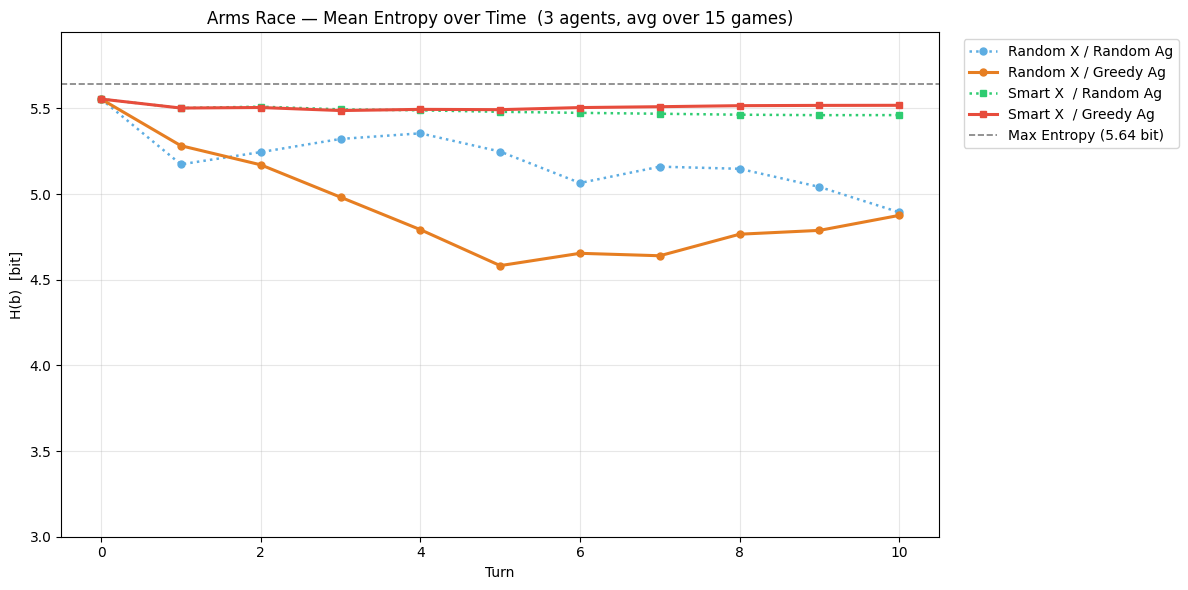

In [34]:
N_AG_EQ  = 3
N_GAMES  = 15   # average over multiple games to avoid lucky/unlucky seeds
SEEDS    = list(range(N_GAMES))

def avg_entropy_curve(run_fn, n_turns, **kwargs):
    """
    Run N_GAMES independent games and return the mean entropy curve,
    padding shorter games (early capture) with their last value.
    """
    curves = []
    for s in SEEDS:
        fb, *_ = run_fn(seed=s, **kwargs)
        ents = [entropy(b) for b in fb]
        # pad to n_turns+1 with the last entropy value
        while len(ents) < n_turns + 1:
            ents.append(ents[-1])
        curves.append(ents[:n_turns + 1])
    return np.mean(curves, axis=0)

curve_RR = avg_entropy_curve(lambda seed: run_game(N_AG_EQ, N_TURNS, strategy='randomic', verbose=False, seed=seed), N_TURNS)
curve_RG = avg_entropy_curve(lambda seed: run_game(N_AG_EQ, N_TURNS, strategy='greedy',   verbose=False, seed=seed), N_TURNS)
curve_SR = avg_entropy_curve(lambda seed: run_game_smart(N_AG_EQ, N_TURNS, agent_strategy='randomic', seed=seed), N_TURNS)
curve_SG = avg_entropy_curve(lambda seed: run_game_smart(N_AG_EQ, N_TURNS, agent_strategy='greedy',   seed=seed), N_TURNS)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(curve_RR, 'o:',  color='#5DADE2', lw=1.8, ms=5, label='Random X / Random Ag')
ax.plot(curve_RG, 'o-',  color='#E67E22', lw=2.2, ms=5, label='Random X / Greedy Ag')
ax.plot(curve_SR, 's:',  color='#2ECC71', lw=1.8, ms=5, label='Smart X  / Random Ag')
ax.plot(curve_SG, 's-',  color='#E74C3C', lw=2.2, ms=5, label='Smart X  / Greedy Ag')

ax.axhline(np.log2(N), color='gray', ls='--', lw=1.2, label=f'Max Entropy ({np.log2(N):.2f} bit)')
ax.set_title(f'Arms Race — Mean Entropy over Time  ({N_AG_EQ} agents, avg over {N_GAMES} games)')
ax.set_xlabel('Turn')
ax.set_ylabel('H(b)  [bit]')
ax.set_ylim(3, np.log2(N) + 0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 8.4 Summary

| Player | Objective | Strategy |
|--------|-----------|----------|
| Mr. X | Maximise $H(b_t)$ | Choose $m^* = \arg\max_m H(T_m^\top \alpha_{t-1})$ |
| Agents | Minimise $H(b_t)$ | Move greedily to $\arg\max_{v \in \mathcal{N}} b_t(v)$ |

These strategies form an **approximate Nash equilibrium**: each is a best-response to the other's current action.

Full game-theoretic optimality would require:
- **Mr. X**: solve a max-entropy MDP (value iteration, intractable exactly)
- **Agents**: solve a cooperative pursuit game (NP-hard, approximated by decentralised greedy)

The key point is that **Sum-Product inference is the backbone of both strategies**: without an accurate belief, neither player can act optimally.

# BONUS

### Multi-step lookahead for Mr. X

The one-step heuristic ignores that a high-entropy move now may lead to a low-entropy region next turn.

1. Implement a **$k$-step lookahead**: simulate $k$ future hypothetical steps (with random agent positions) and pick the transport maximising average entropy over the horizon.
2. Compare capture time as a function of $k$ over 30 random games.

### Coordinated agents

Currently agents move independently on a shared belief. A better strategy partitions the belief and assigns each agent to a region.

1. Implement a **coverage strategy**: sort nodes by belief mass, partition them into $n$ equal-mass regions, and route each agent to the mode of their assigned region.
2. Compare average capture time (over 30 games) with the greedy strategy.